I am going to use Random Search to do initial attempts at hyperparameter optimization. I've chosen Random Search instead of Grid Search because it takes less compute time and produces similar results.

Random Search Optimization uses the following steps which I will apply to my Cabo model using python (https://medium.com/@ergen5171/random-search-optimization-algorithm-048072caea84):

1. Define the function to be optimized.
Win rate of the agent over 20 games.
2. Set search space boundaries.
3. Generate random candidate solutions within the boundaries.
4. Evaluate each candidate using the objective function.
5. Track the best solution found so far.
6. Repeat for a predefined number of iterations.
500 iterations.

I ran 500 iterations with 20 games played in each iteration. For each iteration, the 20 games were seeded the same to give each space boundary combination constant conditions to compare win rate. The "tuned" opponent played against my initial heuristic opponent.

The "first_combination" oppoonent found that the best combo was {'swap_margin': 0.9914362231109511, 'who_has_seen_opponent_card': 3, 'who_has_seen_my_card': 1, 'cabo_known_ratio_threshold': 0.613449352799165, 'cabo_avg_value_threshold': 5.7602470927440885}.

This resulted in a win rate of 50%! 

I ran 1000 games of just this first combination and got a win rate of 37.8%! So, it performs better than my hardcoded strategy! Can we get it to be better than this? Below is showing how well this initial combination performed.

In [ ]:
import glob
import pandas as pd

files = glob.glob("../backend/app/game_logs/random_search_opponent/first_combo (not shuffled)/games_w_combo/*.jsonl")
print(f"{len(files)} game files found")

dfs = [pd.read_json(f, lines=True) for f in files] #each line becomes a df
events = pd.concat(dfs, ignore_index=True) #stacks the indvidual df into one combined df

1000 game files found


Text(0, 0.5, 'Number of wins')

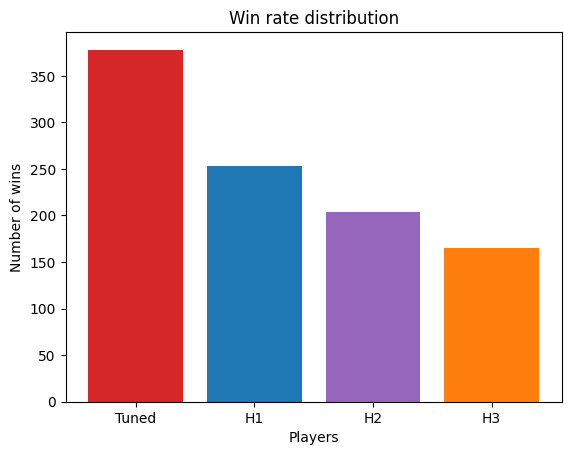

In [10]:

import matplotlib.pyplot as plt
final_winners = events[events.event_type == "final_winner"]

wins = []
players = ["Tuned", "H1", "H2", "H3" ]
for player in players:
    wins.append(final_winners[final_winners.player == player].shape[0])

#can also be done finalwinners.groupby("players").size()
bar_colors = ['tab:red', 'tab:blue', 'tab:purple', 'tab:orange']
plt.bar(players, wins, color = bar_colors)
plt.title("Win rate distribution")
plt.xlabel("Players")
plt.ylabel("Number of wins")

Let's look at which combination factors actually correlated with win rate!

   swap_margin  who_has_seen_opponent_card  who_has_seen_my_card  \
0     1.514901                           4                     3   
1     0.618147                           4                     4   
2     1.696410                           1                     4   
3     0.506520                           3                     4   
4     0.797734                           2                     3   

   cabo_known_ratio_threshold  cabo_avg_value_threshold  win_rate  trial  
0                    0.566163                  2.177660      0.10      0  
1                    0.981373                  3.426532      0.15      1  
2                    0.993429                  4.001228      0.00      2  
3                    0.940093                  4.825202      0.15      3  
4                    0.890749                  5.079192      0.05      4  


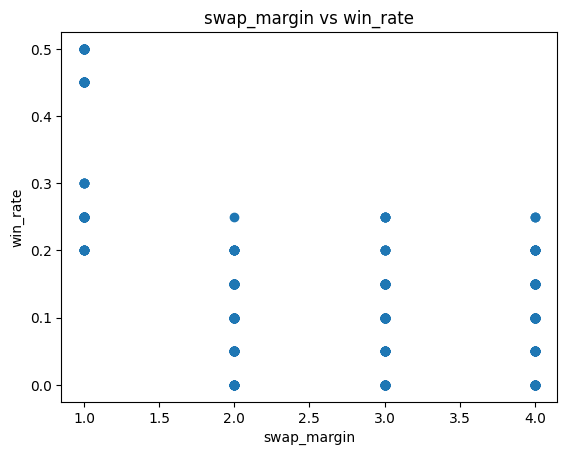

In [ ]:
df = pd.read_csv("../backend/app/game_logs/random_search_opponent/first_combo (not shuffled)/summary_combos (not shuffled)/search_results.csv")
print(df.head())

plt.scatter(df["who_has_seen_my_card"], df["win_rate"])
plt.xlabel("swap_margin")
plt.ylabel("win_rate")
plt.title("swap_margin vs win_rate")
plt.show()


One problem I see right now is that the "Tuned" opponent plays first each round. In a lot of card games, playing firt gives you an advantage. So, I am going to change the code to make player seat also random and increase the number of games played.

From this we get: best combo: {'swap_margin': 2.5317296439162345, 'who_has_seen_opponent_card': 3, 'who_has_seen_my_card': 1, 'cabo_known_ratio_threshold': 0.9197210826801199, 'cabo_avg_value_threshold': 4.0702207810320035}
best win rate : 0.5. So let's run 1000 runs with this combo (also with shuffled seats)

In [19]:
files = glob.glob("../backend/app/game_logs/random_search_opponent/second_combo/games_w_combo/*.jsonl")
print(f"{len(files)} game files found")

dfs = [pd.read_json(f, lines=True) for f in files] #each line becomes a df
events = pd.concat(dfs, ignore_index=True) #stacks the indvidual df into one combined df

1000 game files found


Text(0, 0.5, 'Number of wins')

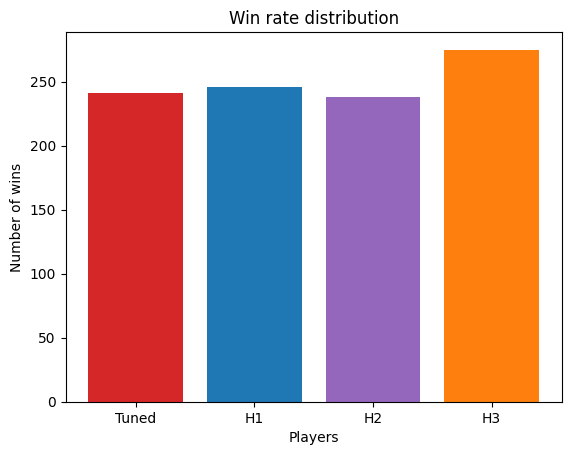

In [20]:

final_winners = events[events.event_type == "final_winner"]

wins = []
players = ["Tuned", "H1", "H2", "H3" ]
for player in players:
    wins.append(final_winners[final_winners.player == player].shape[0])

#can also be done finalwinners.groupby("players").size()
bar_colors = ['tab:red', 'tab:blue', 'tab:purple', 'tab:orange']
plt.bar(players, wins, color = bar_colors)
plt.title("Win rate distribution")
plt.xlabel("Players")
plt.ylabel("Number of wins")

Okay, small problem. Does player order actually matter? Let's see how much "Tuned" won in each position.

In [ ]:
#Used Claude for this, wanted to know quickly what the issue was
initial_reveal_events = events[events.event_type == "initial_reveal"].copy()

# seat = position of this reveal within its own game_id (0,1,2,3)
initial_reveal_events["seat"] = initial_reveal_events.groupby("game_id").cumcount()

# one row per unique game_id, giving Tuned's seat in that game
tuned_seats = (
    initial_reveal_events[initial_reveal_events["player"] == "Tuned"]
    .set_index("game_id")["seat"]
)
final_winner_events = events[events.event_type == "final_winner"]

per_game = final_winner_events[["game_id", "player"]].rename(columns={"player": "final_winner"})
per_game = per_game.merge(tuned_seats.rename("tuned_seat"), on="game_id")
per_game["tuned_won"] = per_game["final_winner"] == "Tuned"
seat_win_rates = per_game.groupby("tuned_seat")["tuned_won"].mean()
seat_counts = per_game.groupby("tuned_seat")["tuned_won"].count()

print("Win rate by seat:")
print(seat_win_rates)
print("\nGames per seat:")
print(seat_counts)
print(f"\nOverall win rate: {per_game['tuned_won'].mean():.3f}")
print(f"Total games: {len(per_game)}")

Win rate by seat:
tuned_seat
0    0.379310
1    0.265455
2    0.184874
3    0.141176
Name: tuned_won, dtype: float64

Games per seat:
tuned_seat
0    232
1    275
2    238
3    255
Name: tuned_won, dtype: int64

Overall win rate: 0.241
Total games: 1000


Ok. So clearly playing in seat 1 gives an advantage. I think what I'll try is that the heuristic "Tuned" model will have 4 configurations based on optimal config for a fixed seat Random Search. Then, when tasked to play, the opponent will first choose the config based on which seat it is in. Let's see if this actually leads to performance gains or is just overfitting.

Combo for seat 1: {'swap_margin': 0.2480052364045473, 'who_has_seen_opponent_card': 4, 'who_has_seen_my_card': 1, 'cabo_known_ratio_threshold': 0.5225398340111305, 'cabo_avg_value_threshold': 5.051835922931348}
best win rate : 0.5
Combo for seat 2: best combo: {'swap_margin': 0.8884917200948299, 'who_has_seen_opponent_card': 4, 'who_has_seen_my_card': 1, 'cabo_known_ratio_threshold': 0.852501307605084, 'cabo_avg_value_threshold': 4.812232478780935}
best win rate : 0.25
Combo for seat 3: best combo: {'swap_margin': 1.2940932001345318, 'who_has_seen_opponent_card': 2, 'who_has_seen_my_card': 1, 'cabo_known_ratio_threshold': 0.6630063949895513, 'cabo_avg_value_threshold': 5.064003460703127}
best win rate : 0.15
Combo for seat 4: {'swap_margin': 0.9724801185035387, 'who_has_seen_opponent_card': 2, 'who_has_seen_my_card': 1, 'cabo_known_ratio_threshold': 0.7347682166995507, 'cabo_avg_value_threshold': 4.238211248410604}
best win rate : 0.15

Based on these win rates, I can already tell that choosing combo will probably have no effect on overall win rate, but let's seen anyway.

In [26]:
files = glob.glob("../backend/app/game_logs/random_search_opponent/multi_combo/games_w_mixed_combo/*.jsonl")
print(f"{len(files)} game files found")

dfs = [pd.read_json(f, lines=True) for f in files] #each line becomes a df
events = pd.concat(dfs, ignore_index=True) #stacks the indvidual df into one combined df

1000 game files found


Text(0, 0.5, 'Number of wins')

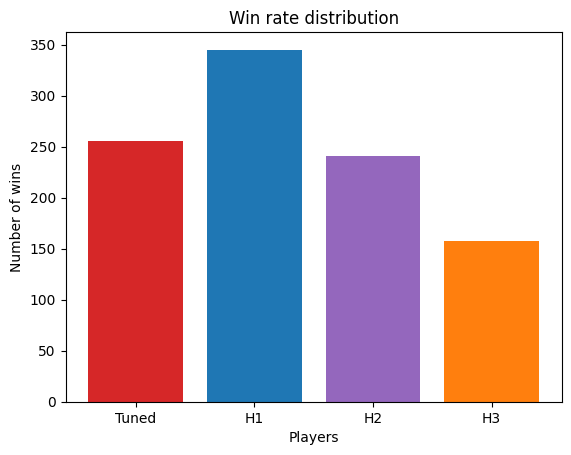

In [27]:

final_winners = events[events.event_type == "final_winner"]

wins = []
players = ["Tuned", "H1", "H2", "H3" ]
for player in players:
    wins.append(final_winners[final_winners.player == player].shape[0])

#can also be done finalwinners.groupby("players").size()
bar_colors = ['tab:red', 'tab:blue', 'tab:purple', 'tab:orange']
plt.bar(players, wins, color = bar_colors)
plt.title("Win rate distribution")
plt.xlabel("Players")
plt.ylabel("Number of wins")

Yeah... no difference. I will leave seat-based strategy to the RL agent later. But I will keep that in mind. H1 here was in first seat other than second seat when "Tuned" was in first. That is why it has the highest wins. Right now, the heuristic bot just takes asvantage of being in first seat for its only wins.